Current working directory: c:\Users\ns087\OneDrive\Documents\GitHub\python_work\Food delivery
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12

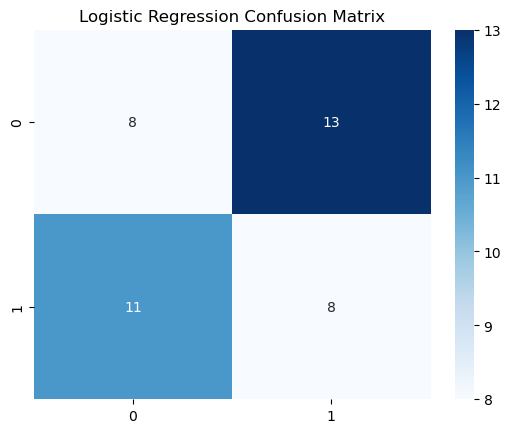

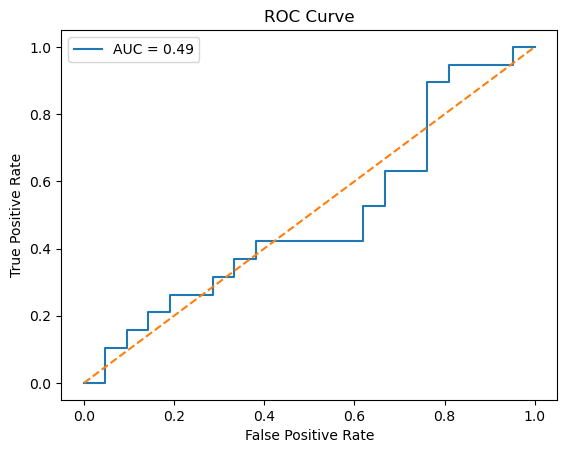

In [1]:
# ================================
# Food Delivery Time Prediction
# ================================

# Phase 1: Data Loading & Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Load dataset
import os
print("Current working directory:", os.getcwd())

# adjust this path to wherever you have placed the CSV;
# using a raw string avoids the unsupported escape sequence warning
data_path = r"C:\Users\ns087\Downloads\Food_Delivery_Time_Prediction.csv"
# or, if you copied the file next to the notebook:
# data_path = "Food_Delivery_Time_Prediction.csv"

if not os.path.isfile(data_path):
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. "
        "Please place the CSV there or update `data_path` accordingly."
    )

df = pd.read_csv(data_path)

# Inspect data
print(df.info())
print(df.head())

# Handle missing values
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# ================================
# Phase 2: Feature Engineering
# ================================

# Haversine formula to calculate distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R * c

# Function to parse location string into latitude and longitude
def parse_location_string(location_str):
    try:
        # Remove parentheses and split by comma
        lat_str, lon_str = location_str.strip('()').split(', ')
        return float(lat_str), float(lon_str)
    except (ValueError, AttributeError):
        return np.nan, np.nan # Handle cases where parsing might fail

# Apply the parsing function to create lat/lon columns
df[['Restaurant_lat', 'Restaurant_lon']] = df['Restaurant_Location'].apply(lambda x: pd.Series(parse_location_string(x)))
df[['Customer_lat', 'Customer_lon']] = df['Customer_Location'].apply(lambda x: pd.Series(parse_location_string(x)))

# Fill any NaNs that resulted from parsing errors (e.g., if a location string was malformed)
for col in ['Restaurant_lat', 'Restaurant_lon', 'Customer_lat', 'Customer_lon']:
    df[col] = df[col].fillna(df[col].median())

# Now call haversine using the extracted lat/lon columns
df['Distance'] = haversine(df['Restaurant_lat'], df['Restaurant_lon'],
                           df['Customer_lat'], df['Customer_lon'])

# Encode categorical variables
categorical_cols = ['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type', 'Order_Priority', 'Order_Time']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])



# Outlier treatment using IQR
def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    # Modify the DataFrame directly without chained assignment
    df.loc[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR), col] = np.nan
    df[col] = df[col].fillna(df[col].median())

# Apply outlier treatment to relevant columns
for col in ['Distance','Delivery_Time']:
    remove_outliers(col)

# ================================
# Phase 3: Model Preparation
# ================================

# Define features (X) and target (y)
X = df.drop(columns=['Delivery_Time', 'Order_ID', 'Customer_Location', 'Restaurant_Location',
                     'Restaurant_lat', 'Restaurant_lon', 'Customer_lat', 'Customer_lon'], errors='ignore')
y = df['Delivery_Time']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ================================
# Phase 4: Model Training & Comparison
# ================================

# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_val)


y_binary = (y < y.median()).astype(int)  # Fast=1, Delayed=0
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Scale X_train_bin and X_test_bin for Logistic Regression separately if needed, or use the main scaler
scaler_log = StandardScaler()
X_train_bin_scaled = scaler_log.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_log.transform(X_test_bin)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_bin_scaled, y_train_bin)
y_pred_log = log_reg.predict(X_test_bin_scaled)

# ================================
# Phase 5: Prediction Function
# ================================

def predict_delivery_time(order_details, model=lin_reg, scaler=scaler):
    """
    order_details: dict with keys matching feature names
    Returns predicted delivery time in minutes
    """
    try:
        input_df = pd.DataFrame([order_details])


        input_scaled = scaler.transform(input_df)
        prediction = model.predict(input_scaled)[0]
        return {
            "Predicted_Delivery_Time": round(prediction,2),
            "Confidence_Score": None,  # can be added with probabilistic models
            "Key_Contributing_Factors": list(order_details.keys())
        }
    except Exception as e:
        return {"error": str(e)}

# ================================
# Phase 6: Evaluation
# ================================

print("Linear Regression MAE:", mean_absolute_error(y_val, y_pred_lin))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_lin)))
print("Linear Regression R2:", r2_score(y_val, y_pred_lin))

print("Logistic Regression Accuracy:", accuracy_score(y_test_bin, y_pred_log))
print("Precision:", precision_score(y_test_bin, y_pred_log))
print("Recall:", recall_score(y_test_bin, y_pred_log))
print("F1 Score:", f1_score(y_test_bin, y_pred_log))

# Confusion Matrix
cm = confusion_matrix(y_test_bin, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_bin, log_reg.predict_proba(X_test_bin_scaled)[:,1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()